[23:05:04] (load_picam_data) Loading picamera data for experiment 20241216_e01

[23:05:04] (find_picams) 2 picamera(s) found: ['pic1', 'pic2']

[23:05:04] (load_picam_metadata) pic1 metadata loaded!
[23:05:04] (load_picamera_clock_data) pic1 frame time data loaded!
[23:05:04] (load_picam_LED_data) LED intensity values loaded!

[23:05:04] (load_picam_metadata) pic2 metadata loaded!
[23:05:04] (load_picamera_clock_data) pic2 frame time data loaded!
[23:05:04] (load_picam_LED_data) LED intensity values loaded!

[23:05:04] (load_picam_data) PICAM Acquisition SUMMARY:

   Metadata (pic1):
   Framerate [fps]: 40.0
   Video duration [min]: 10.0
   Resolution [px]: (1280, 720)
   Shutter speed [us]: 3000.0
   Bitrate [bit/sec]: 7000000

   Metadata (pic2):
   Framerate [fps]: 40.0
   Video duration [min]: 10.0
   Resolution [px]: (1280, 720)
   Shutter speed [us]: 3000.0
   Bitrate [bit/sec]: 7000000


[23:05:04] (analyze_picam_times) Analyzing picam frame times for experiment 20241216_e01:

F

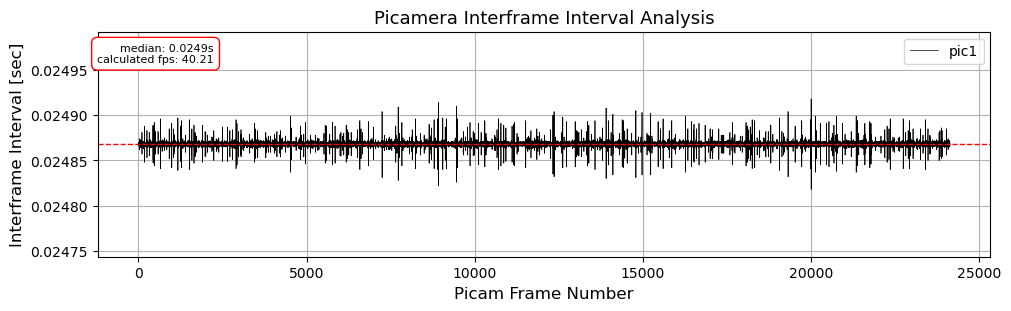


Frame analysis for pic2:
   Total number of picam frames found: 24122
   Total number of dropped picam frames: 0


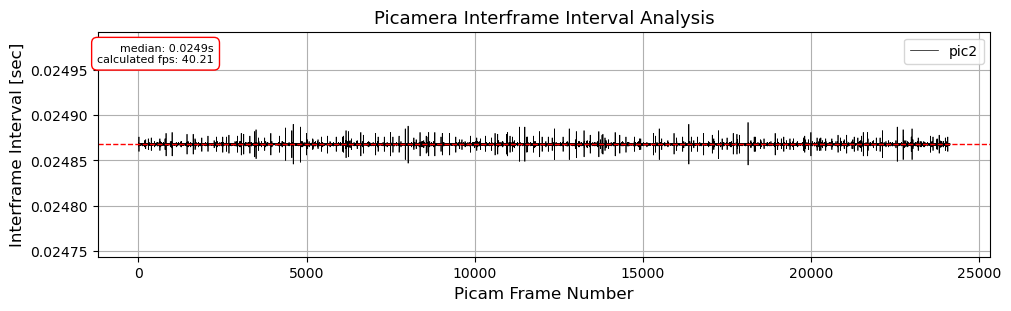


[23:05:05] (analyze_picam_times) Analysis of picam frame timing completed for experiment 20241216_e01.


[23:05:05] (load_daq_data) Loading DAQ data for experiment 20241216_e01

[23:05:05] (load_daq_data) Loaded: daq_arduino_voltage.csv

-------------------------------------------------------------------------------------------------------------

[23:05:10] (synchronize_daq_picameras) Synchronizing DAQ and PiCamera data for experiment 20241216_e01
                                   using ROI intensity-voltage matching of the same blinking LED.

[23:05:10] (initialize_sync_dict) Calculate lag between DAQ signal and pic1 using cross-correlation.
[23:05:11] (determine_picam_daq_drift_and_plot) 695 Blink-Edges pairs found for pic1.
[23:05:11] (find_outliers_regression) 144 outlier Blink-Edge pairs found and replaced for pic1 
                                      using a time difference threshold of ±30.00 msecs!

[23:05:11] (determine_picam_daq_drift_and_plot) pic1 slope:     -0.000018
 

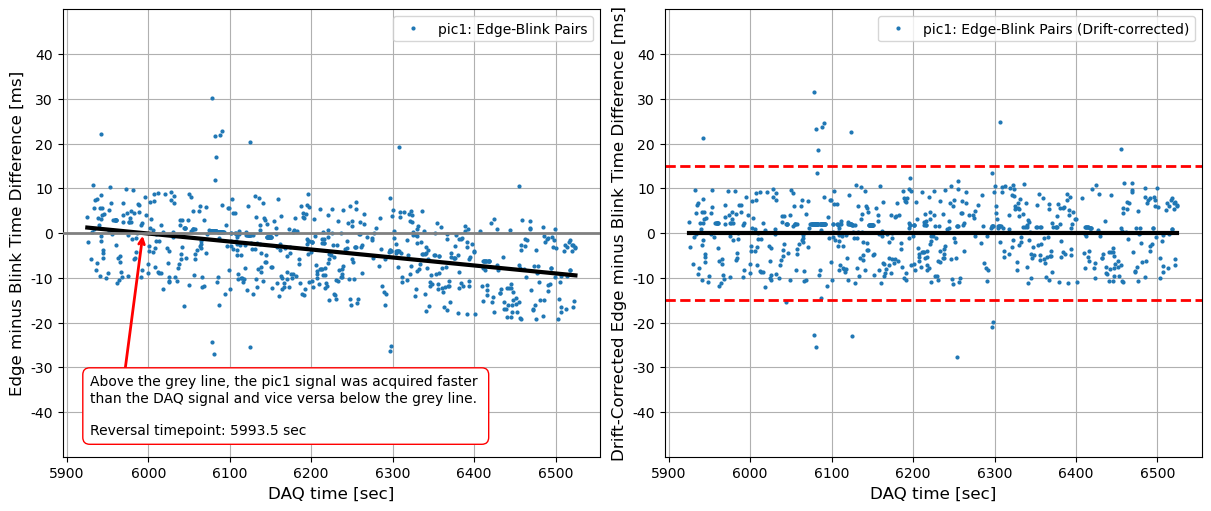


[23:05:11] (initialize_sync_dict) Calculate lag between DAQ signal and pic2 using cross-correlation.
[23:05:12] (determine_picam_daq_drift_and_plot) 1959 Blink-Edges pairs found for pic2.
[23:05:12] (find_outliers_regression) 9 outlier Blink-Edge pairs found and replaced for pic2 
                                      using a time difference threshold of ±30.00 msecs!

[23:05:12] (determine_picam_daq_drift_and_plot) pic2 slope:     -0.000012
                                               pic2 intercept:  0.074339



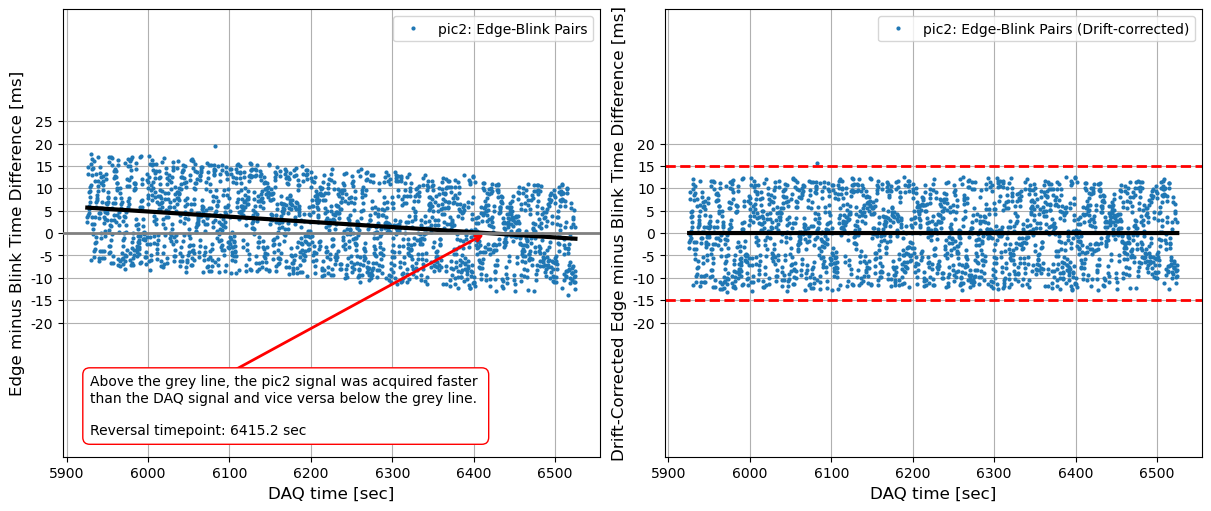


[23:05:12] (synchronize_daq_picameras) PICAM-DAQ synchronization SUMMARY:

            pic1-DAQ lag (sec): 74.9500
            pic2-DAQ lag (sec): 74.9100
            lagPicam1-lagPicam2 (sec): 0.0400


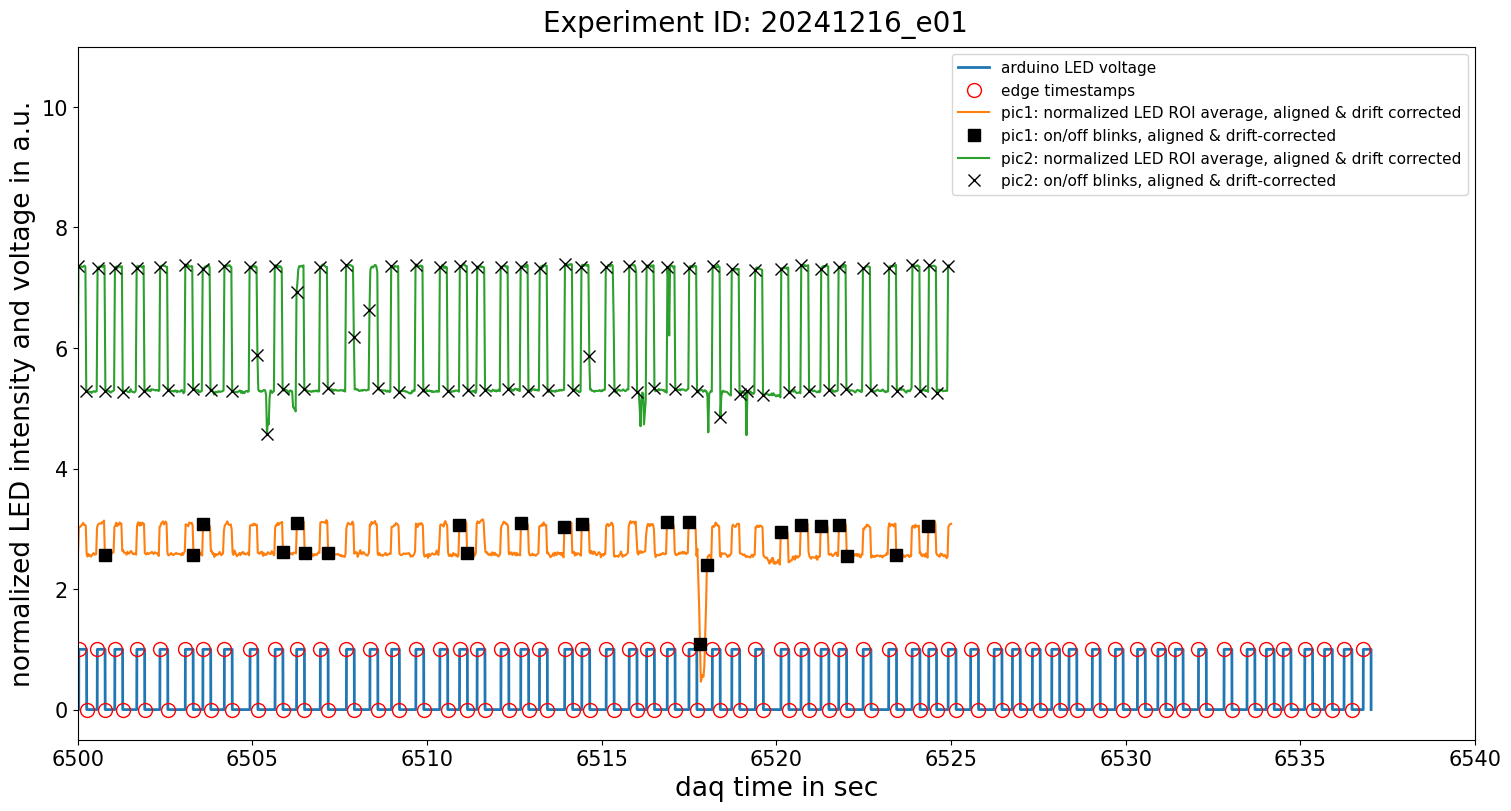

In [1]:
# Standard library imports
import getpass
import matplotlib.pyplot as plt

from modules import picam_data_loader
from modules import picam_data_analysis
from modules import daq_data_loader
from modules import sync_daq_picam 

user = getpass.getuser()
datadir    = '/home/' + user + '/Desktop/picam_sync_neuro/testdata/'
#datadir    = '/media/' + user + '/DATA/picam_sync_neuro/testdata/'

expID      = '20241216_e01'

picam_dict = picam_data_loader.load_picam_data(datadir, expID, verbose=True)
picam_dict = picam_data_analysis.analyze_picam_times(datadir, expID, picam_dict, verbose=True)

daq_dict = daq_data_loader.load_daq_data(datadir, expID, daq_frequency=3000)

sync_dict = sync_daq_picam.synchronize_daq_picameras(datadir, expID, picam_dict, daq_dict, verbose=True)

sync_daq_picam.plot_picam_daq_sync_data(datadir, expID, picam_dict, daq_dict, sync_dict, xmin=6500, xmax=6540)

In [4]:
sync_dict

{'expID': '20241216_e01',
 'sync_data_save_datetime': '2025-02-25 23:05:10',
 'picam_list': ['pic1', 'pic2'],
 'PICAM_DAQ_sync_run': True,
 'pic1': {'lag_picam_sec': 5925.137487999999,
  'model_parameters': [-1.783076203132391e-05, 0.10686819277469753],
  'picam_LEDsignal_drft_corr':        frame_time_sec  LED_ROI_avg  daq_time_sec
  frame                                           
  0            0.000000    -0.774309   5925.138706
  1            0.024868    -0.755178   5925.163574
  2            0.049736    -0.738273   5925.188442
  3            0.074604     0.069960   5925.213309
  4            0.099472     0.025921   5925.238177
  ...               ...          ...           ...
  24118      599.769314     0.036386   6524.897326
  24119      599.794182     0.535731   6524.922194
  24120      599.819050     0.561776   6524.947061
  24121      599.843919     0.576739   6524.971930
  24122      599.868787     0.581996   6524.996797
  
  [24123 rows x 3 columns],
  'picam_LED_blinks_drf